# 냉매 물성 데이터 탐색 (PubChem 수집 결과)

수집된 데이터의 품질 확인, 분포 시각화, 결측값 분석을 수행합니다.

In [11]:
import sys
sys.path.append("..")  # 상위 디렉토리(Refrigerant_Prediction/) 인식

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── 한글 폰트 설정 (Windows: 맑은 고딕) ─────────────────────────────────────
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ── 데이터 경로 ───────────────────────────────────────────────────────────────
PROCESSED = Path("../data/processed/refrigerants_final.csv")
RAW       = Path("../data/raw/refrigerants_raw.csv")

def load(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"[!] 파일 없음: {path}")
        print("    run_pipeline.py 를 먼저 실행하세요.")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"로드 완료: {path.name}  →  {df.shape[0]}행 × {df.shape[1]}열")
    return df

df = load(PROCESSED) if PROCESSED.exists() else load(RAW)
df

로드 완료: refrigerants_final.csv  →  485행 × 23열


,identifier,cid,CID,MolecularFormula,MolecularWeight,SMILES,ConnectivitySMILES,InChI,InChIKey,IUPACName,...,has_stereo,source_thermo,Tc_K,Pc_MPa,omega,label,group,error,valid,validation_notes
0,R-41,11638.0,11638.0,CH3F,34.033,CF,CF,InChI=1S/CH3F/c1-2/h1H3,NBVXSUQYWXRMNV-UHFFFAOYSA-N,fluoromethane,...,False,CoolProp,317.2791,5.906115,0.200400,1,C1_moderate_F,NaN,True,OK
1,R-32,6345.0,6345.0,CH2F2,52.023,C(F)F,C(F)F,InChI=1S/CH2F2/c2-1-3/h1H2,RWRIWBAIICGTTQ-UHFFFAOYSA-N,difluoromethane,...,False,CoolProp,351.2550,5.782645,0.276900,1,C1_moderate_F,NaN,True,OK
2,R-23,6373.0,6373.0,CHF3,70.014,C(F)(F)F,C(F)(F)F,InChI=1S/CHF3/c2-1(3)4/h1H,XPDWGBQVDMORPB-UHFFFAOYSA-N,fluoroform,...,False,NIST,299.1000,4.828000,0.261018,1,C1_moderate_F,NaN,True,OK
3,R-40,6327.0,6327.0,CH3Cl,50.490,CCl,CCl,InChI=1S/CH3Cl/c1-2/h1H3,NEHMKBQYUWJMIP-UHFFFAOYSA-N,chloromethane,...,False,CoolProp,418.6257,6.929003,0.150068,1,C1_moderate_F,NaN,True,OK
4,Ethylene,6325.0,6325.0,C2H4,28.050,C=C,C=C,InChI=1S/C2H4/c1-2/h1-2H2,VGGSQFUCUMXWEO-UHFFFAOYSA-N,ethene,...,False,CoolProp,282.3500,5.041692,0.086600,1,C2_doublebond_F,NaN,True,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,Succinimide,11439.0,11439.0,C4H5NO2,99.090,C1CC(=O)NC1=O,C1CC(=O)NC1=O,"InChI=1S/C4H5NO2/c6-3-1-2-4(7)5-3/h1-2H2,(H,5,...",KZNICNPSHKQLFF-UHFFFAOYSA-N,"pyrrolidine-2,5-dione",...,False,Manual,820.0000,4.600000,0.540000,0,amide_lactam,NaN,True,OK
481,"1,2-Dichloropentane",15481.0,15481.0,C5H10Cl2,141.040,CCCC(CCl)Cl,CCCC(CCl)Cl,"InChI=1S/C5H10Cl2/c1-2-3-5(7)4-6/h5H,2-4H2,1H3",PPLBPDUKNRCHGG-UHFFFAOYSA-N,"1,2-dichloropentane",...,False,Manual,638.0000,3.700000,0.330000,0,halo_C5C6_add,NaN,True,OK
482,1-Chloro-2-MethylPropane,10554.0,10554.0,C4H9Cl,92.570,CC(C)CCl,CC(C)CCl,"InChI=1S/C4H9Cl/c1-4(2)3-5/h4H,3H2,1-2H3",QTBFPMKWQKYFLR-UHFFFAOYSA-N,1-chloro-2-methylpropane,...,False,Manual,538.0000,4.100000,0.261000,0,halo_C5C6_add,NaN,True,OK
483,3-Chloropropene,7850.0,7850.0,C3H5Cl,76.520,C=CCCl,C=CCCl,"InChI=1S/C3H5Cl/c1-2-3-4/h2H,1,3H2",OSDWBNJEKMUWAV-UHFFFAOYSA-N,3-chloroprop-1-ene,...,False,Manual,514.1000,4.730000,0.174000,0,halo_C5C6_add,NaN,True,OK


In [12]:
df.columns

Index(['identifier', 'cid', 'CID', 'MolecularFormula', 'MolecularWeight',
       'SMILES', 'ConnectivitySMILES', 'InChI', 'InChIKey', 'IUPACName',
       'XLogP', 'HeavyAtomCount', 'smiles_source', 'has_stereo',
       'source_thermo', 'Tc_K', 'Pc_MPa', 'omega', 'label', 'group', 'error',
       'valid', 'validation_notes'],
      dtype='object')

In [13]:
df["inchikey_base"] = df["InChIKey"].str[:14]

# 같은 base를 가진 그룹만 필터링
base_counts = df[df["InChIKey"].notna()]["inchikey_base"].value_counts()
isomer_bases_list = base_counts[base_counts > 1].index

isomer_groups = (
    df[df["inchikey_base"].isin(isomer_bases_list)]
    .sort_values("inchikey_base")[
        ["identifier", "inchikey_base", "InChIKey", "SMILES", "has_stereo", "Tc_K", "Pc_MPa", "omega"]
    ]
)

print(f"이성질체 포함 화합물: {len(isomer_groups)}개")
print(f"이성질체 그룹 수: {len(isomer_bases_list)}개\n")


이성질체 포함 화합물: 15개
이성질체 그룹 수: 7개



In [14]:
df[["smiles_source","source_thermo","SMILES","Tc_K","Pc_MPa","omega"]].groupby(["smiles_source","source_thermo"]).count()

SMILES  Tc_K  Pc_MPa  omega
smiles_source source_thermo                             
Manual        CoolProp            1     1       1      1
              Manual              8     8       8      8
              NIST+Manual         1     1       1      1
PubChem       CoolProp          111   111     111    111
              Manual            181   181     181    181
              NIST              141   139     139    139
              NIST+Manual        41    41      41     41

## 1. 기본 정보 확인

In [15]:
print("=== 컬럼 목록 ===")
print(df.columns.tolist())

print("\n=== 데이터 타입 & 결측 수 ===")
info = pd.DataFrame({
    "dtype":   df.dtypes,
    "non_null": df.notna().sum(),
    "missing":  df.isna().sum(),
    "missing%": (df.isna().mean() * 100).round(1),
})
info

=== 컬럼 목록 ===
['identifier', 'cid', 'CID', 'MolecularFormula', 'MolecularWeight', 'SMILES', 'ConnectivitySMILES', 'InChI', 'InChIKey', 'IUPACName', 'XLogP', 'HeavyAtomCount', 'smiles_source', 'has_stereo', 'source_thermo', 'Tc_K', 'Pc_MPa', 'omega', 'label', 'group', 'error', 'valid', 'validation_notes', 'inchikey_base']

=== 데이터 타입 & 결측 수 ===


,dtype,non_null,missing,missing%
identifier,object,485,0,0.0
cid,float64,479,6,1.2
CID,float64,478,7,1.4
MolecularFormula,object,485,0,0.0
MolecularWeight,float64,485,0,0.0
SMILES,object,484,1,0.2
ConnectivitySMILES,object,484,1,0.2
InChI,object,484,1,0.2
InChIKey,object,484,1,0.2
IUPACName,object,477,8,1.6


In [5]:
# 핵심 물성 컬럼만 추려서 한눈에 보기
KEY_COLS = ["identifier", "cid", "MolecularFormula", "MolecularWeight",
            "Tc_K", "Pc_MPa", "omega", "CanonicalSMILES"]
existing = [c for c in KEY_COLS if c in df.columns]

df[existing].style \
    .format({"MolecularWeight": "{:.2f}", "Tc_K": "{:.2f}",
             "Pc_MPa": "{:.4f}", "omega": "{:.4f}"}, na_rep="—") \
    .background_gradient(subset=[c for c in ["Tc_K","Pc_MPa","omega"] if c in existing],
                         cmap="YlOrRd")

,identifier,cid,MolecularFormula,MolecularWeight,Tc_K,Pc_MPa,omega
0,R-41,11638.000000,CH3F,34.03,317.28,5.9061,0.2004
1,R-32,6345.000000,CH2F2,52.02,351.25,5.7826,0.2769
2,R-23,6373.000000,CHF3,70.01,299.10,4.8280,0.2610
3,R-40,6327.000000,CH3Cl,50.49,418.63,6.9290,0.1501
4,Ethylene,6325.000000,C2H4,28.05,282.35,5.0417,0.0866
5,R-161,9620.000000,C2H5F,48.06,375.25,5.0100,0.2162
6,R-152a,6368.000000,C2H4F2,66.05,386.41,4.5168,0.2752
7,R-143a,9868.000000,C2H3F3,84.04,345.86,3.7618,0.2615
8,R-134a,13129.000000,C2H2F4,102.03,374.21,4.0593,0.3268
9,R-125,9633.000000,C2HF5,120.02,339.18,3.6183,0.3052


## 2. 결측값 시각화

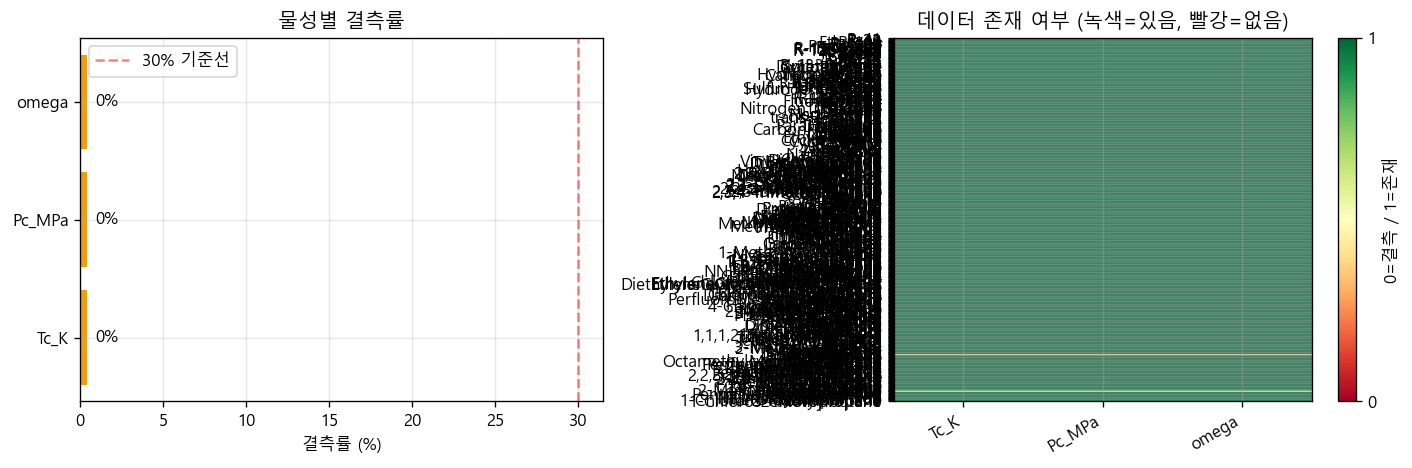

In [6]:
prop_cols = [c for c in ["Tc_K", "Pc_MPa", "omega",
                          "boiling_point", "melting_point"] if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── 왼쪽: 결측률 막대 ──────────────────────────────────────────────────────
missing_pct = df[prop_cols].isna().mean() * 100
colors = ["#e74c3c" if v > 30 else "#f39c12" if v > 0 else "#2ecc71"
          for v in missing_pct]
axes[0].barh(prop_cols, missing_pct, color=colors)
axes[0].axvline(30, color="red", linestyle="--", alpha=0.5, label="30% 기준선")
axes[0].set_xlabel("결측률 (%)")
axes[0].set_title("물성별 결측률")
axes[0].legend()
for i, v in enumerate(missing_pct):
    axes[0].text(v + 0.5, i, f"{v:.0f}%", va="center")

# ── 오른쪽: 히트맵(화합물 × 물성) ────────────────────────────────────────
avail = df[prop_cols].notna().astype(int)
im = axes[1].imshow(avail.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_xticks(range(len(prop_cols)))
axes[1].set_xticklabels(prop_cols, rotation=30, ha="right")
axes[1].set_yticks(range(len(df)))
axes[1].set_yticklabels(df["identifier"] if "identifier" in df.columns else df.index)
axes[1].set_title("데이터 존재 여부 (녹색=있음, 빨강=없음)")
plt.colorbar(im, ax=axes[1], ticks=[0, 1], label="0=결측 / 1=존재")

plt.tight_layout()
plt.show()

## 3. 물성 분포

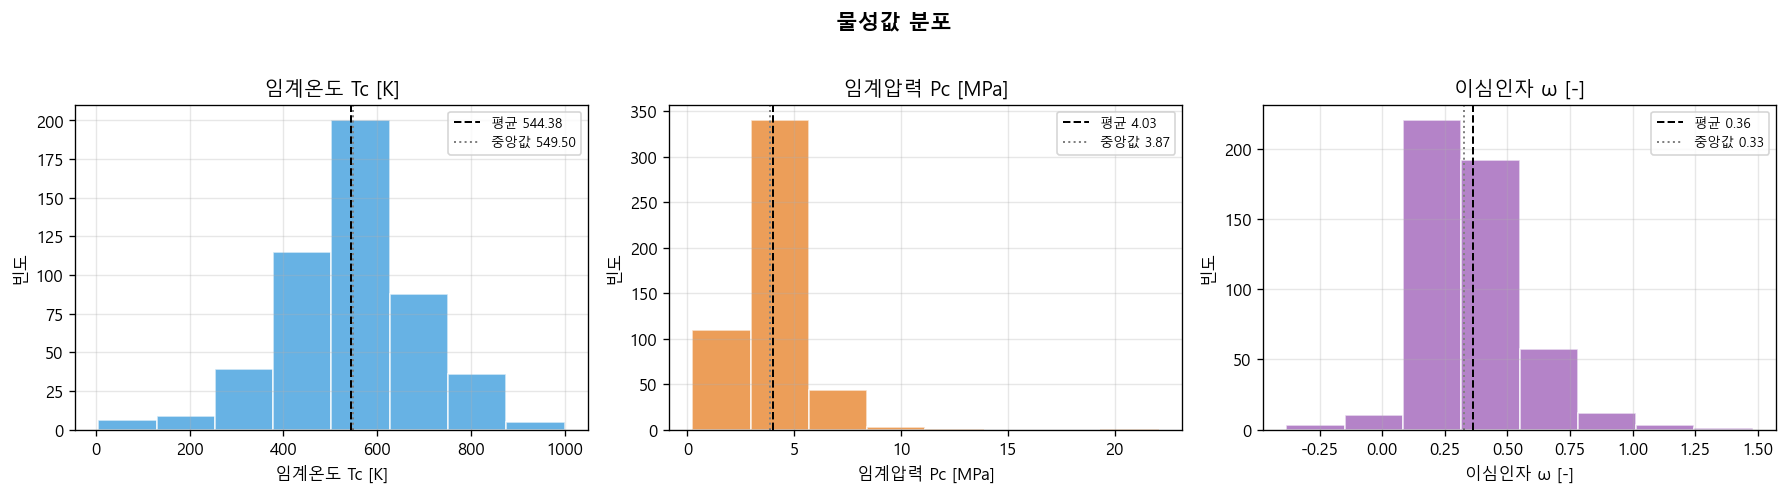

,Tc_K,Pc_MPa,omega
count,498.000,498.000,498.000
mean,544.380,4.026,0.364
std,147.319,1.659,0.191
min,5.195,0.228,-0.384
25%,457.622,3.102,0.249
50%,549.500,3.865,0.327
75%,631.000,4.770,0.452
max,1000.000,22.064,1.480


In [7]:
plot_props = [
    ("Tc_K",   "임계온도 Tc [K]",       "#3498db"),
    ("Pc_MPa", "임계압력 Pc [MPa]",     "#e67e22"),
    ("omega",  "이심인자 ω [-]",        "#9b59b6"),
]
plot_props = [(c, l, col) for c, l, col in plot_props if c in df.columns]

fig, axes = plt.subplots(1, len(plot_props), figsize=(5 * len(plot_props), 4))
if len(plot_props) == 1:
    axes = [axes]

for ax, (col, label, color) in zip(axes, plot_props):
    data = df[col].dropna()
    ax.hist(data, bins=8, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"평균 {data.mean():.2f}")
    ax.axvline(data.median(), color="gray", linestyle=":", linewidth=1.2,
               label=f"중앙값 {data.median():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("빈도")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("물성값 분포", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 기술통계
df[[c for c, _, _ in plot_props]].describe().round(3)

## 4. 화합물별 물성 비교 (막대 차트)

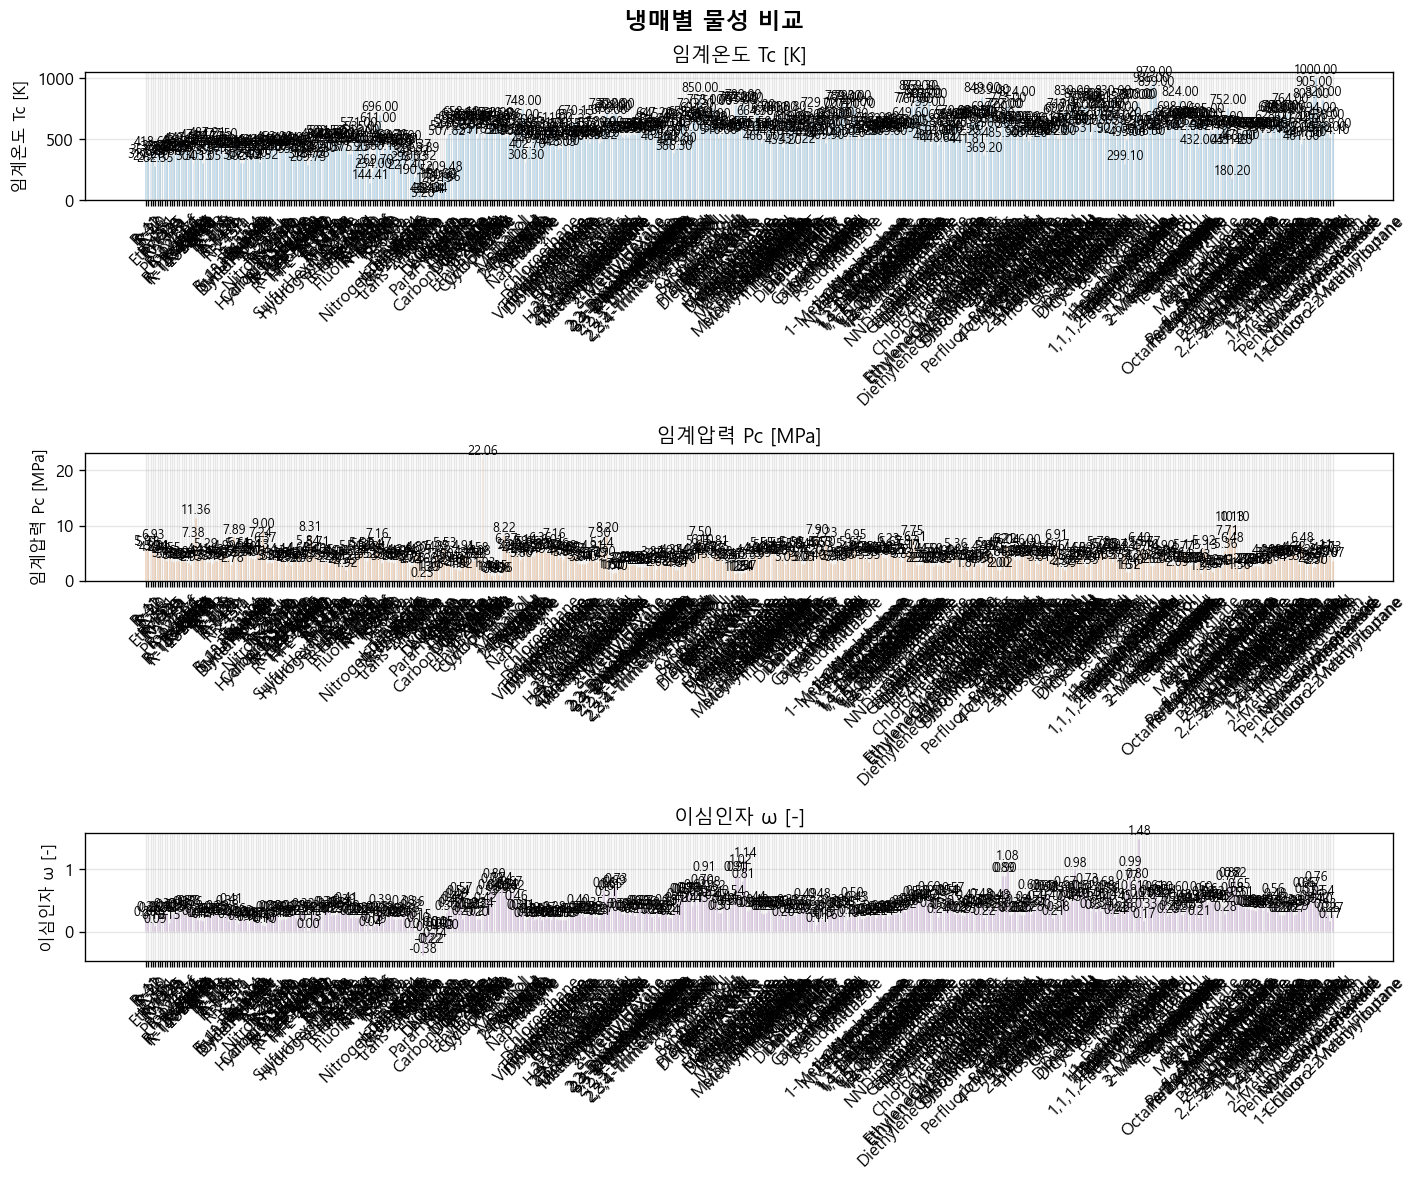

In [8]:
label_col = "identifier" if "identifier" in df.columns else df.index

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
bar_props = [
    ("Tc_K",   "임계온도 Tc [K]",   "#3498db"),
    ("Pc_MPa", "임계압력 Pc [MPa]", "#e67e22"),
    ("omega",  "이심인자 ω [-]",    "#9b59b6"),
]

for ax, (col, ylabel, color) in zip(axes, bar_props):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    sub = df[[label_col, col]].dropna(subset=[col]).copy()
    bars = ax.bar(sub[label_col], sub[col], color=color, alpha=0.8, edgecolor="white")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.tick_params(axis="x", rotation=45)
    # 값 레이블
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)

plt.suptitle("냉매별 물성 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. 물성 간 상관관계

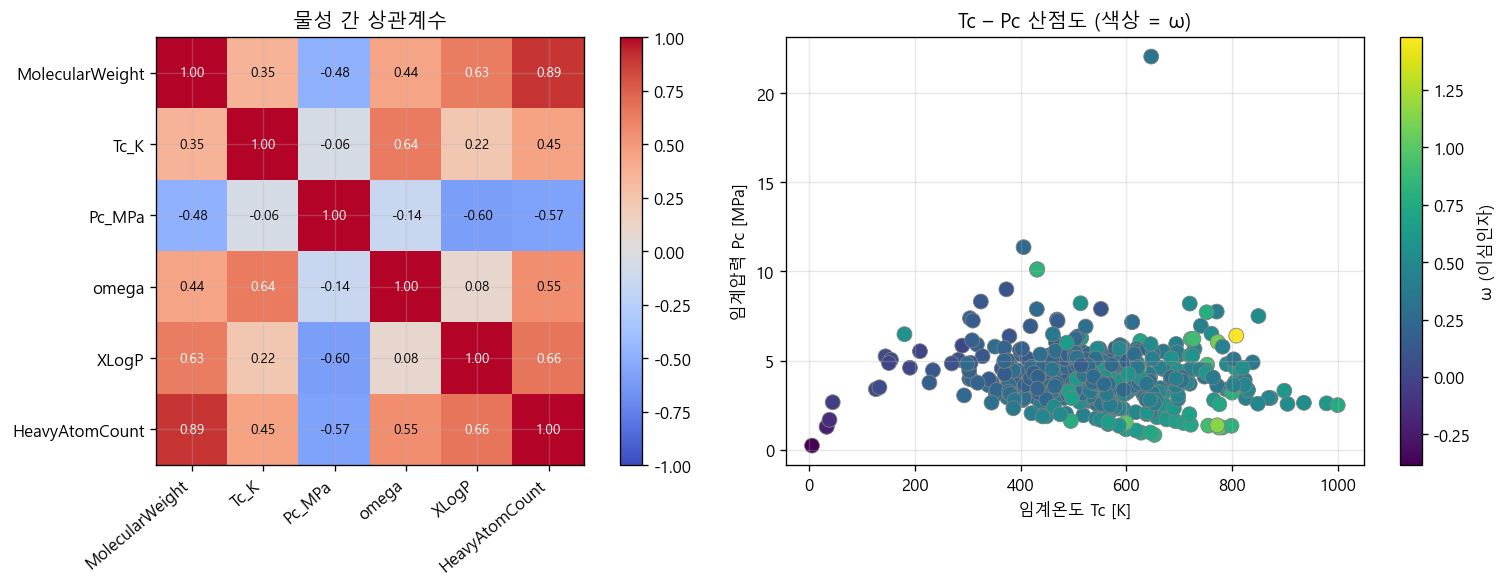

In [9]:
num_cols = [c for c in ["MolecularWeight", "Tc_K", "Pc_MPa", "omega",
                         "XLogP", "HeavyAtomCount"] if c in df.columns]
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 히트맵 ──────────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors
im = axes[0].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(num_cols)))
axes[0].set_yticks(range(len(num_cols)))
axes[0].set_xticklabels(num_cols, rotation=40, ha="right")
axes[0].set_yticklabels(num_cols)
plt.colorbar(im, ax=axes[0])
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}",
                     ha="center", va="center", fontsize=8,
                     color="white" if abs(corr.iloc[i,j]) > 0.6 else "black")
axes[0].set_title("물성 간 상관계수")

# ── Tc vs Pc 산점도 ──────────────────────────────────────────────────────
if "Tc_K" in df.columns and "Pc_MPa" in df.columns:
    sub = df.dropna(subset=["Tc_K", "Pc_MPa"])
    sc = axes[1].scatter(sub["Tc_K"], sub["Pc_MPa"],
                         c=sub.get("omega", pd.Series([0]*len(sub))),
                         cmap="viridis", s=80, edgecolors="gray", linewidths=0.5)
    plt.colorbar(sc, ax=axes[1], label="ω (이심인자)")
    # for _, row in sub.iterrows():
    #     axes[1].annotate(row.get("identifier", ""), (row["Tc_K"], row["Pc_MPa"]),
    #                      fontsize=7, xytext=(4, 3), textcoords="offset points")
    axes[1].set_xlabel("임계온도 Tc [K]")
    axes[1].set_ylabel("임계압력 Pc [MPa]")
    axes[1].set_title("Tc – Pc 산점도 (색상 = ω)")

plt.tight_layout()
plt.show()

## 6. 분자구조 확인 (RDKit)

[20:37:00] WARNING: not removing hydrogen atom without neighbors
[20:37:00] WARNING: not removing hydrogen atom without neighbors
c:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


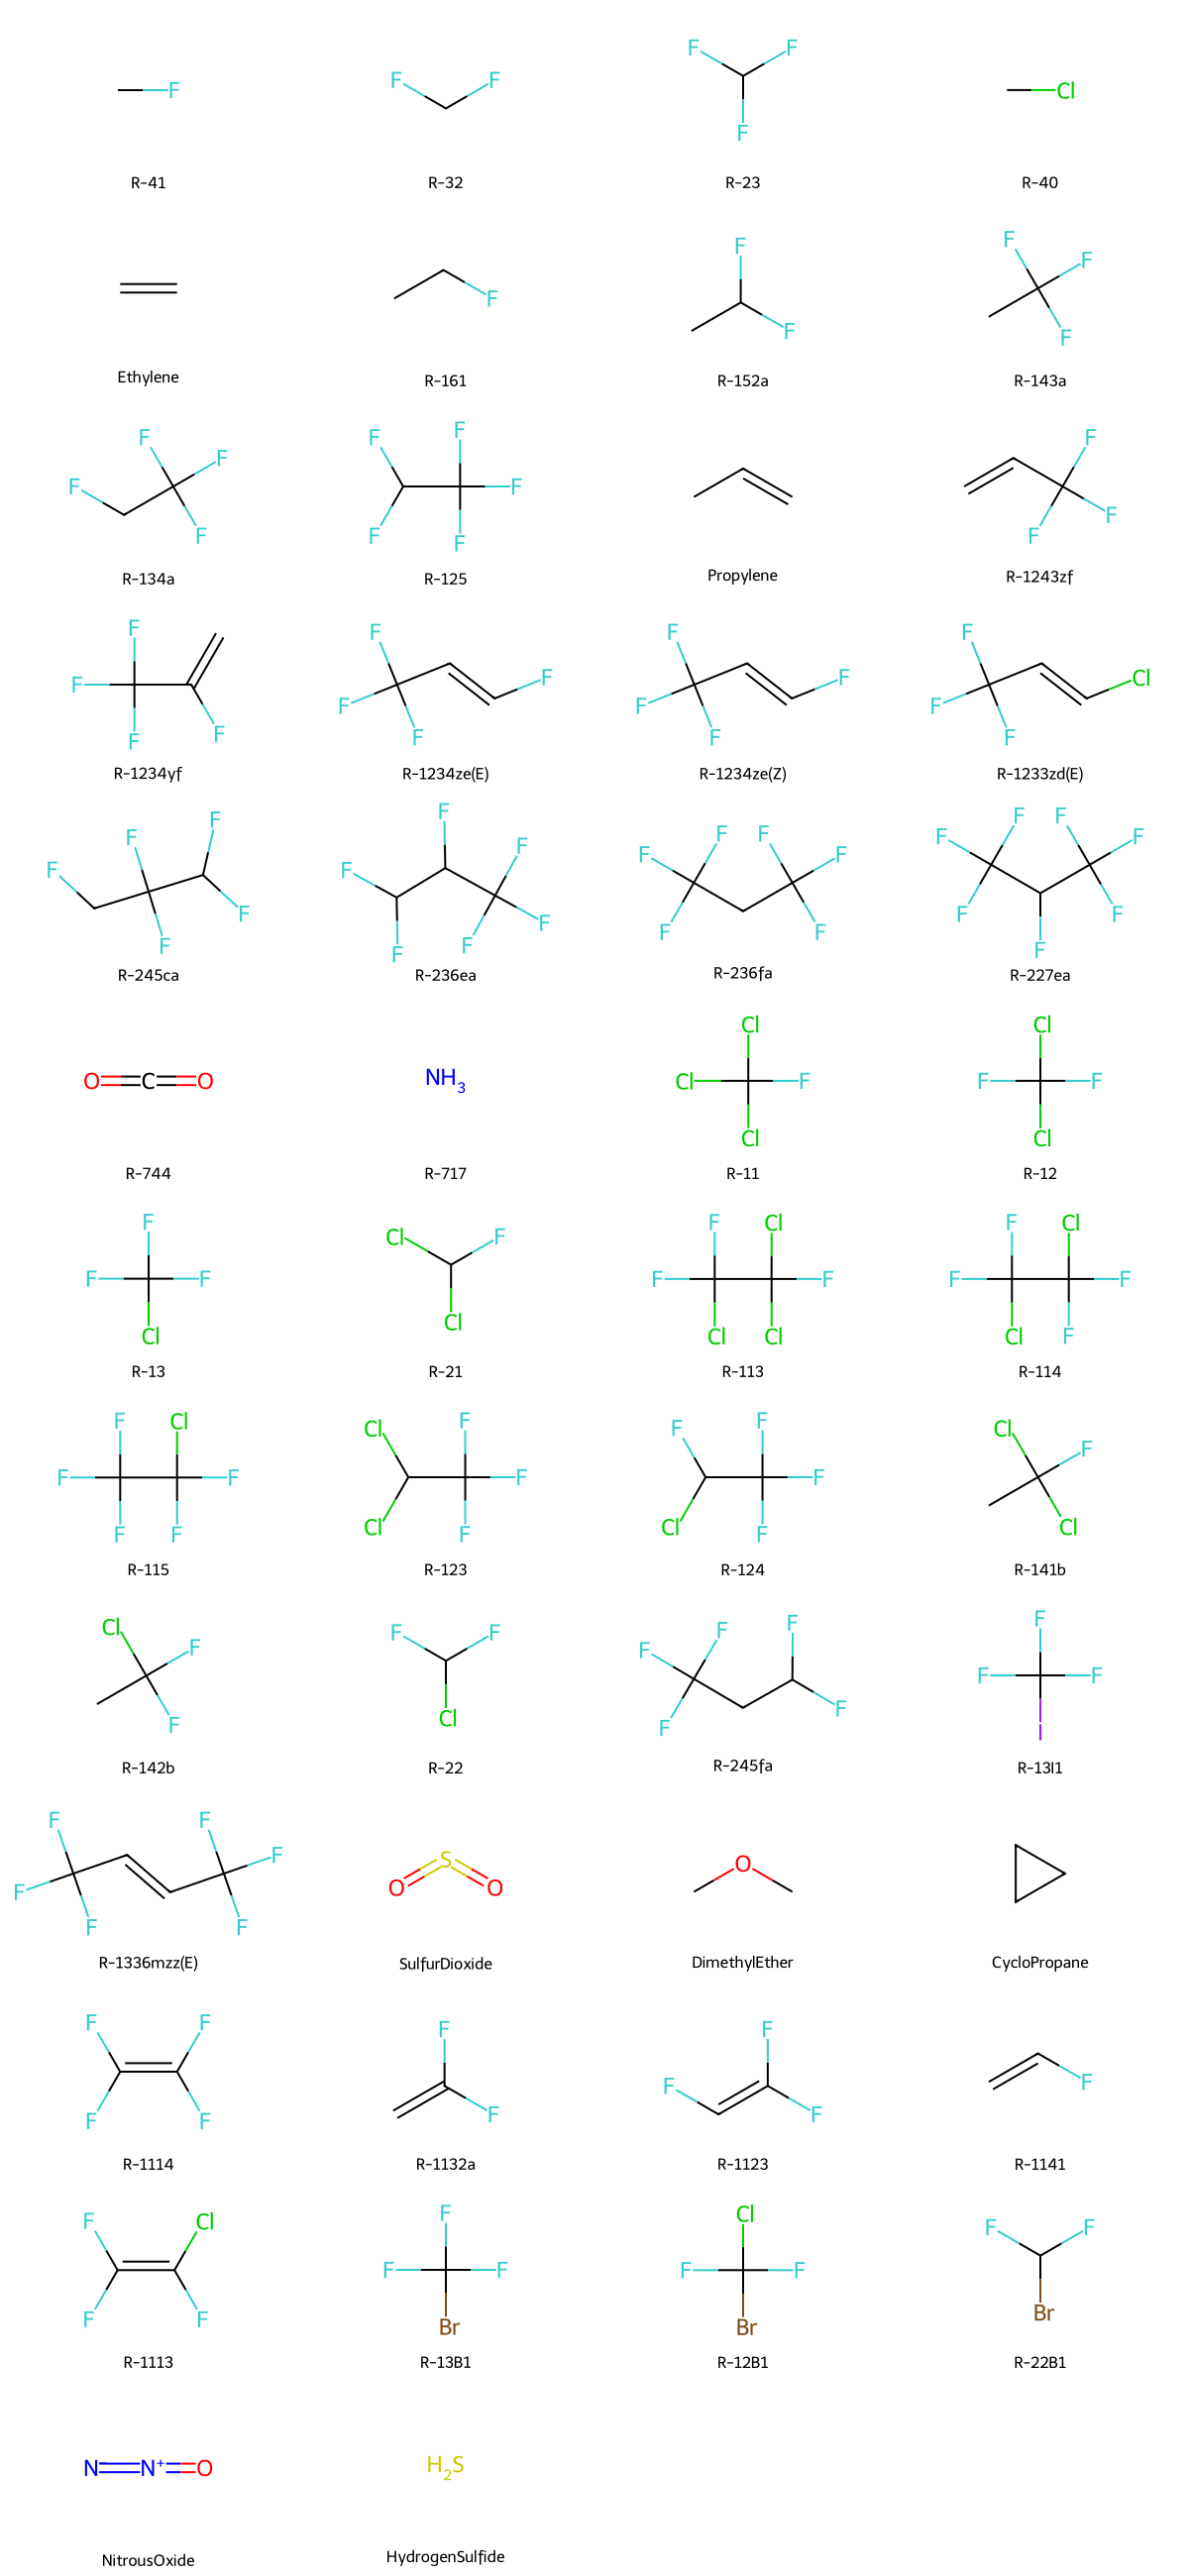

In [10]:
try:
    from rdkit import Chem
    from rdkit.Chem import Draw
    from IPython.display import display

    # 존재하는 SMILES 컬럼 찾기
    smiles_col = next(
        (c for c in ["CanonicalSMILES", "IsomericSMILES", "SMILES"] if c in df.columns),
        None
    )

    if smiles_col is None:
        print("[!] SMILES 컬럼이 없습니다. run_pipeline.py 를 먼저 실행하세요.")
    else:
        sub = df[["identifier", smiles_col]].dropna(subset=[smiles_col])

        mols, legends = [], []
        for _, row in sub.iterrows():
            mol = Chem.MolFromSmiles(row[smiles_col])
            if mol:
                mols.append(mol)
                legends.append(row["identifier"])

        img = Draw.MolsToGridImage(
            mols, molsPerRow=4,
            subImgSize=(300, 200),
            legends=legends,
        )
        display(img)

except ImportError:
    print("[!] RDKit이 설치되어 있지 않습니다.  pip install rdkit")
    smiles_col = next((c for c in ["CanonicalSMILES", "SMILES"] if c in df.columns), None)
    if smiles_col:
        print(df[["identifier", smiles_col]].to_string(index=False))

## 7. 유효 데이터 필터링 & 저장

In [12]:
# Tc, Pc, ω 세 값이 모두 있는 행만 추출 → 모델 학습용 데이터
required = [c for c in ["Tc_K", "Pc_MPa", "omega"] if c in df.columns]
df_model = df.dropna(subset=required).reset_index(drop=True)

print(f"전체: {len(df)}행  →  완전 데이터(Tc+Pc+ω): {len(df_model)}행")

out_path = Path("../data/processed/refrigerants_model_ready.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_model.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"저장: {out_path}")

df_model[["identifier", "MolecularFormula", "SMILES",
          "Tc_K", "Pc_MPa", "omega"]].style \
    .format({"Tc_K": "{:.2f}", "Pc_MPa": "{:.4f}", "omega": "{:.4f}"}) \
    .background_gradient(cmap="Blues", subset=["Tc_K", "Pc_MPa", "omega"])

전체: 500행  →  완전 데이터(Tc+Pc+ω): 498행
저장: ..\data\processed\refrigerants_model_ready.csv


,identifier,MolecularFormula,SMILES,Tc_K,Pc_MPa,omega
0,R-41,CH3F,CF,317.28,5.9061,0.2004
1,R-32,CH2F2,C(F)F,351.25,5.7826,0.2769
2,R-23,CHF3,C(F)(F)F,299.10,4.8280,0.2610
3,R-40,CH3Cl,CCl,418.63,6.9290,0.1501
4,Ethylene,C2H4,C=C,282.35,5.0417,0.0866
5,R-161,C2H5F,CCF,375.25,5.0100,0.2162
6,R-152a,C2H4F2,CC(F)F,386.41,4.5168,0.2752
7,R-143a,C2H3F3,CC(F)(F)F,345.86,3.7618,0.2615
8,R-134a,C2H2F4,C(C(F)(F)F)F,374.21,4.0593,0.3268
9,R-125,C2HF5,C(C(F)(F)F)(F)F,339.18,3.6183,0.3052
